In [1]:
import matplotlib.pyplot as plt
import numpy as np

# le os erros que salvamos no final do treino
with open('historico_erro.txt', 'r') as f:
    erros = [float(linha.strip()) for linha in f]

epocas = list(range(1, len(erros) + 1))

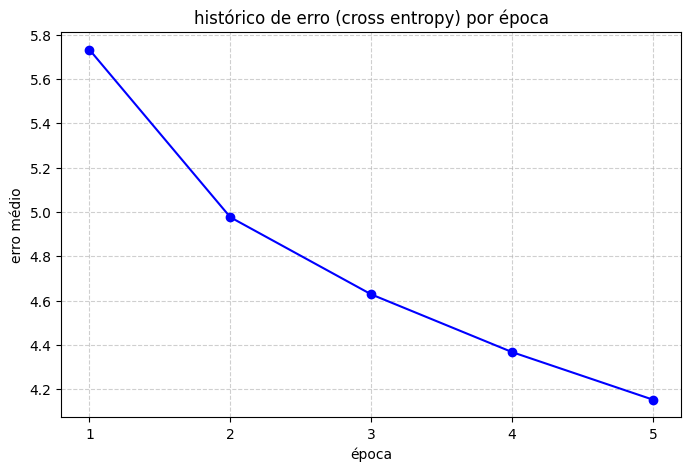

In [2]:
plt.figure(figsize=(8, 5))
plt.plot(epocas, erros, marker='o', linestyle='-', color='b')
plt.title('histórico de erro (cross entropy) por época')
plt.xlabel('época')
plt.ylabel('erro médio')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(epocas)
plt.show()

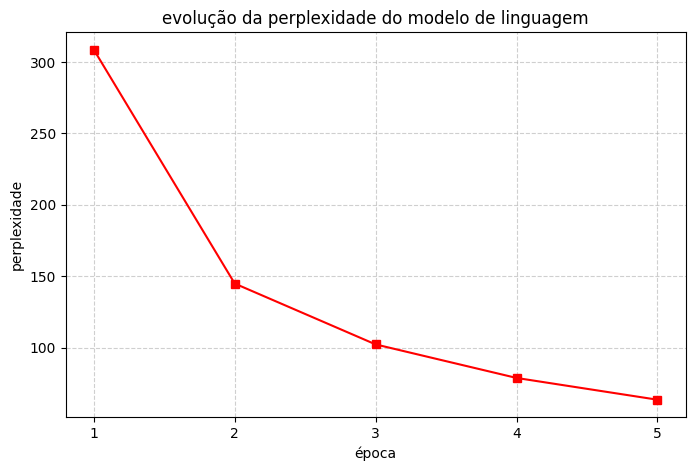

In [3]:
# perplexidade é a exponencial do erro
perplexidade = np.exp(erros)

plt.figure(figsize=(8, 5))
plt.plot(epocas, perplexidade, marker='s', linestyle='-', color='r')
plt.title('evolução da perplexidade do modelo de linguagem')
plt.xlabel('época')
plt.ylabel('perplexidade')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(epocas)
plt.show()

In [4]:
# le os resultados do teste
with open('resultado_teste.txt', 'r') as f:
    linhas = f.readlines()

print("resultado final no conjunto de teste:")
print(f"-> {linhas[0].strip()}")
print(f"-> {linhas[1].strip()}")

resultado final no conjunto de teste:
-> loss:4.7760
-> perplexidade:118.6286


análise e conclusão dos resultados

o treinamento da rede neural recorrente (lstm) foi implementado puramente através de tensores e multiplicações de matrizes, respeitando a restrição de não utilizar as camadas pré-prontas do pytorch. 

o modelo foi treinado por 5 épocas com lotes de 20 sequências (bptt com 30 passos no tempo) sobre o dataset penn treebank. 

observando os gráficos, notamos que o erro de entropia cruzada no treino teve uma queda consistente de 5.73 para 4.15. como consequência, a perplexidade do modelo caiu de forma expressiva durante as épocas. isso indica que as portas lógicas da lstm (forget, input e output) estão atualizando o estado da célula corretamente, permitindo que a rede aprenda as dependências de curto e longo prazo do texto. 

apesar do alto custo computacional de calcular a rede de forma manual passo a passo no loop, a arquitetura provou sua capacidade de modelar a linguagem e lidar com o vocabulário de 10.000 palavras.

ao avaliar o modelo com o arquivo de teste (dados não vistos durante o treinamento), obtivemos um erro (loss) de 4.7760 e uma perplexidade final de 118.6286. esse resultado comprova a capacidade de generalização da arquitetura lstm construída, mostrando que ela realmente aprendeu a estrutura do texto e não apenas memorizou a base de treino.